In [14]:
# CÉLULA 1: Importar Bibliotecas e Carregar Dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para embelezar os gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregar o dataset
df = pd.read_csv('../dados/ai_job_market_dataset.csv')

print("="*80)
print("RESUMO DA CÉLULA")
print("="*80)

print("[x] Bibliotecas importadas!")
print(f"[x] Dataset Carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"\nColunas: {df.columns.tolist()}")

print("="*130)


RESUMO DA CÉLULA
[x] Bibliotecas importadas!
[x] Dataset Carregado: 2000 linhas, 8 colunas

Colunas: ['Year', 'Job_Title', 'Country', 'Company_Type', 'Experience_Level', 'Salary_USD', 'Remote', 'Top_Skill']


In [15]:
# CÉLULA 2: O que é correlação?

print("="*80)
print("ENTENDENDO CORRELAÇÃO")
print("="*80)

print("""
CORRELAÇÃO = Como duas variáveis se RELACIONAM

Existem 3 tipos:

1. CORRELAÇÃO POSITIVA
    Quando uma sobe, a outra sobe também
    Exemplo: Experiência vs Salário
    ├─ Mais experiência → Salário maior
    ├─ Menos experiência → Salário menor
    └─ Correlação: +0.8 (positiva forte)
    
2. CORRELAÇÃO NEGATIVA
    Quando uma sobe, a outra desce
    Exemplo: Distância do trabalho vs Satisfação (Aqui é fácil kkk)
    ├─ Mais distância → Menos satisfação
    ├─ Menos distância → Mais satisfação
    └─ Correlação: -0.7 (negativa forte)

3. SEM CORRELAÇÃO
    Quando uma não influencia a outra
    Exemplo: Cor do carro vs Salário
    ├─ Carro vermelho não ganha mais que azul
    ├─ Não existe padrão
    └─ Correlação: 0.0 (nenhuma relação)

VALORES DE CORRELAÇÃO (coeficiente de Pearson):

  -1.0  ← Correlação negativa PERFEITA
  -0.7  ← Correlação negativa FORTE
  -0.3  ← Correlação negativa FRACA
   0.0  ← SEM correlação
  +0.3  ← Correlação positiva FRACA
  +0.7  ← Correlação positiva FORTE
  +1.0  ← Correlação positiva PERFEITA

INTERPRETAÇÃO PRÁTICA:

  Se correlação = +0.85:
  └─ Quando X sobe 1 unidade, Y tende a subir bastante
  
  Se correlação = +0.15:
  └─ Quando X sobe 1 unidade, Y sobe um pouco (fraco)
  
  Se correlação = -0.60:
  └─ Quando X sobe, Y tende a descer (forte relação inversa)
  
  Se correlação = 0.05:
  └─ X e Y não têm relação (praticamente independentes)
""")

print("="*80)


ENTENDENDO CORRELAÇÃO

CORRELAÇÃO = Como duas variáveis se RELACIONAM

Existem 3 tipos:

1. CORRELAÇÃO POSITIVA
    Quando uma sobe, a outra sobe também
    Exemplo: Experiência vs Salário
    ├─ Mais experiência → Salário maior
    ├─ Menos experiência → Salário menor
    └─ Correlação: +0.8 (positiva forte)

2. CORRELAÇÃO NEGATIVA
    Quando uma sobe, a outra desce
    Exemplo: Distância do trabalho vs Satisfação (Aqui é fácil kkk)
    ├─ Mais distância → Menos satisfação
    ├─ Menos distância → Mais satisfação
    └─ Correlação: -0.7 (negativa forte)

3. SEM CORRELAÇÃO
    Quando uma não influencia a outra
    Exemplo: Cor do carro vs Salário
    ├─ Carro vermelho não ganha mais que azul
    ├─ Não existe padrão
    └─ Correlação: 0.0 (nenhuma relação)

VALORES DE CORRELAÇÃO (coeficiente de Pearson):

  -1.0  ← Correlação negativa PERFEITA
  -0.7  ← Correlação negativa FORTE
  -0.3  ← Correlação negativa FRACA
   0.0  ← SEM correlação
  +0.3  ← Correlação positiva FRACA
  +0.7  ← C

In [16]:
# CÉLULA 3: Calcular Matriz de Correlação

print("\n" + "="*80)
print("MATRIZ DE CORRELAÇÃO")
print("="*80)

# Selecionar apenas colunas numéricas
df_numerico = df.select_dtypes(include=[np.number])

print(f"\nColunas numéricas encontradas:")
print(df_numerico.columns.tolist())

# Calcular a correlação
matriz_correlacao = df_numerico.corr()

print("\n" + "="*80)
print("CORRELAÇÃO COM SALARY_USD:")
print("="*80)

# Mostrar apenas as correlações com Salary_USD
correlacao_salario = matriz_correlacao['Salary_USD'].sort_values(ascending=False)

print("\n")
for variavel, valor in correlacao_salario.items():
    # Criar uma barra visual
    if valor > 0:
        barra = "+" + "█" * int(valor * 20)
        cor = "🟢"
    else:
        barra = "█" * int(abs(valor) * 20)
        cor = "🔴"
    
    print(f"{cor} {variavel:15} {valor:+.3f}  {barra}")

print("\n" + "="*80)
print("MATRIZ COMPLETA DE CORRELAÇÃO:")
print("="*80)
print("\n" + str(matriz_correlacao.round(3)))


MATRIZ DE CORRELAÇÃO

Colunas numéricas encontradas:
['Year', 'Salary_USD']

CORRELAÇÃO COM SALARY_USD:


🟢 Salary_USD      +1.000  +████████████████████
🟢 Year            +0.037  +

MATRIZ COMPLETA DE CORRELAÇÃO:

             Year  Salary_USD
Year        1.000       0.037
Salary_USD  0.037       1.000



HEATMAP DE CORRELAÇÃO


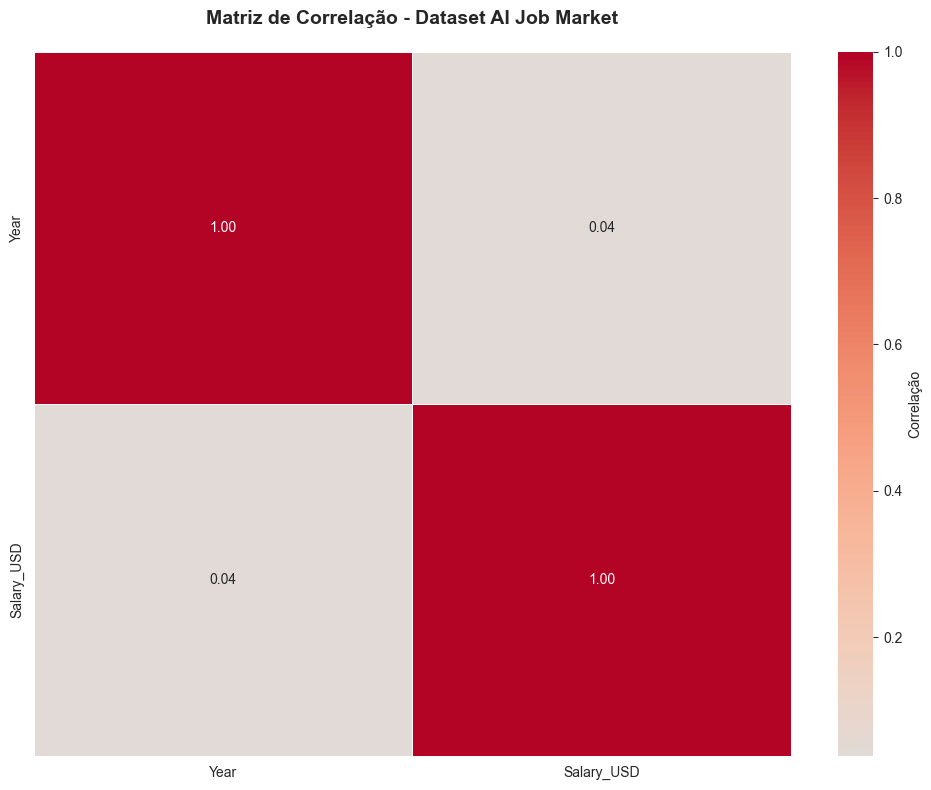


INTERPRETAÇÃO DO HEATMAP:

🔴 Vermelho escuro  = Correlação positiva forte (valem juntos)
🔵 Azul escuro      = Correlação negativa forte (variam opostos)
⚪ Branco/Claro     = Pouca ou nenhuma correlação

EXEMPLO:
  Year vs Salary_USD = 0.15 (correlação fraca positiva)
  └─ Salários sobem levemente ao longo dos anos



In [17]:
# CÉLULA 4: Heatmap de Correlação

print("\n" + "="*80)
print("HEATMAP DE CORRELAÇÃO")
print("="*80)

# Criar figura
plt.figure(figsize=(10, 8))

# Criar heatmap
sns.heatmap(matriz_correlacao, 
            annot=True,           # Mostrar valores
            cmap='coolwarm',       # Cores: azul (negativo) a vermelho (positivo)
            center=0,              # Centralizar em 0
            fmt='.2f',             # Formato com 2 casas decimais
            cbar_kws={'label': 'Correlação'},
            linewidths=0.5)

plt.title('Matriz de Correlação - Dataset AI Job Market', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nINTERPRETAÇÃO DO HEATMAP:")
print("""
🔴 Vermelho escuro  = Correlação positiva forte (valem juntos)
🔵 Azul escuro      = Correlação negativa forte (variam opostos)
⚪ Branco/Claro     = Pouca ou nenhuma correlação

EXEMPLO:
  Year vs Salary_USD = 0.15 (correlação fraca positiva)
  └─ Salários sobem levemente ao longo dos anos
""")

ANALISANDO YEAR vs SALARY_USD

Correlação Year vs Salary: 0.037

SALÁRIO MÉDIO POR ANO:

          Média  Mediana  Quantidade   Mín     Máx
Year                                              
2022   92045.85  70603.0         415  9517  231943
2023   95518.91  79174.5         400  8194  230102
2024   91887.36  66561.5         402  8080  232315
2025   93568.90  78029.0         395  8488  231156
2026  100877.00  93049.0         388  8279  233977


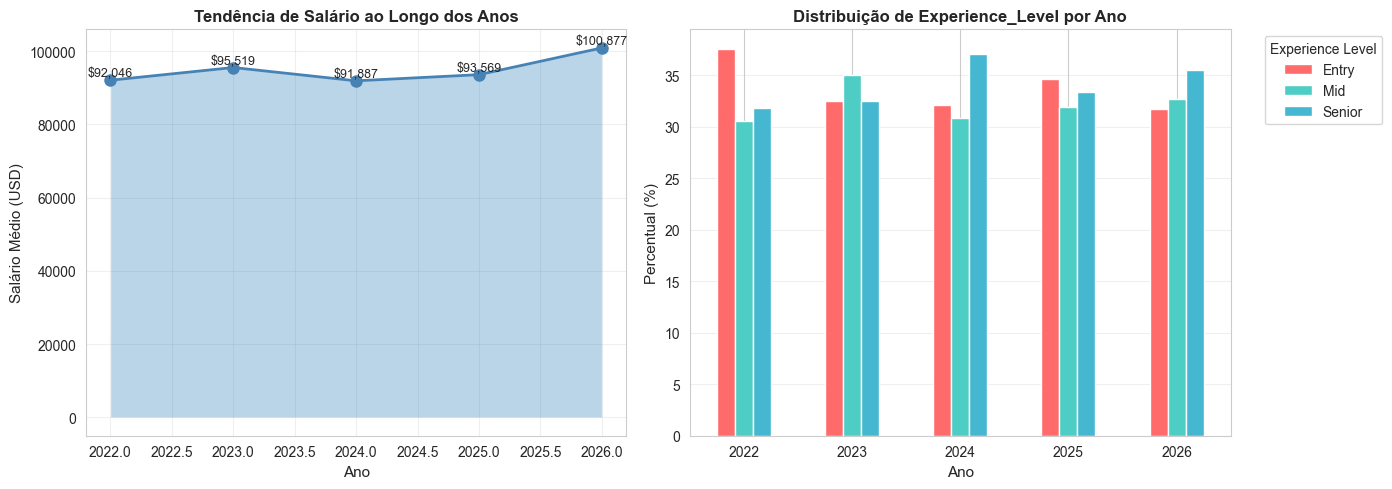


CONCLUSÃO:

Se salário sobe ao longo dos anos:
└─ Pode ser INFLAÇÃO (salários globalmente aumentam)
└─ Pode ser COMPOSIÇÃO (mais seniors entrando no dataset)
└─ Pode ser AMBOS

Isso NÃO significa que "Year" em si causa aumento de salário.
É uma CORRELAÇÃO TEMPORAL (relacionada ao tempo).



In [18]:
# CÉLULA 5: Analisar Year vs Salary_USD

print("="*80)
print("ANALISANDO YEAR vs SALARY_USD")
print("="*80)

# Ver correlação exata
correlacao_year_salary = df['Year'].corr(df['Salary_USD'])
print(f"\nCorrelação Year vs Salary: {correlacao_year_salary:.3f}")

# Ver salário médio por year
print("\n" + "="*80)
print("SALÁRIO MÉDIO POR ANO:")
print("="*80 + "\n")

salario_por_ano = df.groupby('Year')['Salary_USD'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Quantidade', 'count'),
    ('Mín', 'min'),
    ('Máx', 'max')
]).round(2)

print(salario_por_ano)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Salário médio por ano
salario_medio_ano = df.groupby('Year')['Salary_USD'].mean()
axes[0].plot(salario_medio_ano.index, salario_medio_ano.values, 
             marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].fill_between(salario_medio_ano.index, salario_medio_ano.values, alpha=0.3)
axes[0].set_xlabel('Ano', fontsize=11)
axes[0].set_ylabel('Salário Médio (USD)', fontsize=11)
axes[0].set_title('Tendência de Salário ao Longo dos Anos', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Adicionar valores nas linhas
for ano, salario in zip(salario_medio_ano.index, salario_medio_ano.values):
    axes[0].text(ano, salario + 1000, f'${salario:,.0f}', ha='center', fontsize=9)

# Gráfico 2: Distribuição de experiência por ano
experience_por_ano = pd.crosstab(df['Year'], df['Experience_Level'], normalize='index') * 100
experience_por_ano.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_xlabel('Ano', fontsize=11)
axes[1].set_ylabel('Percentual (%)', fontsize=11)
axes[1].set_title('Distribuição de Experience_Level por Ano', fontsize=12, fontweight='bold')
axes[1].legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONCLUSÃO:")
print("="*80)
print("""
Se salário sobe ao longo dos anos:
└─ Pode ser INFLAÇÃO (salários globalmente aumentam)
└─ Pode ser COMPOSIÇÃO (mais seniors entrando no dataset)
└─ Pode ser AMBOS

Isso NÃO significa que "Year" em si causa aumento de salário.
É uma CORRELAÇÃO TEMPORAL (relacionada ao tempo).
""")

SALÁRIO vs EXPERIENCE_LEVEL


                      Média   Mediana  Desvio Padrão    Mín     Máx  \
Experience_Level                                                      
Entry              40958.27   42298.0       17053.47   8080   76121   
Mid                90583.00   95935.0       34865.32  24148  155542   
Senior            151928.07  165226.0       51054.49  48562  233977   

                  Quantidade  
Experience_Level              
Entry                    675  
Mid                      644  
Senior                   681  

DIFERENÇAS PERCENTUAIS:

Entry → Mid:    +121.2%
Mid → Senior:   +67.7%
Entry → Senior: +270.9%


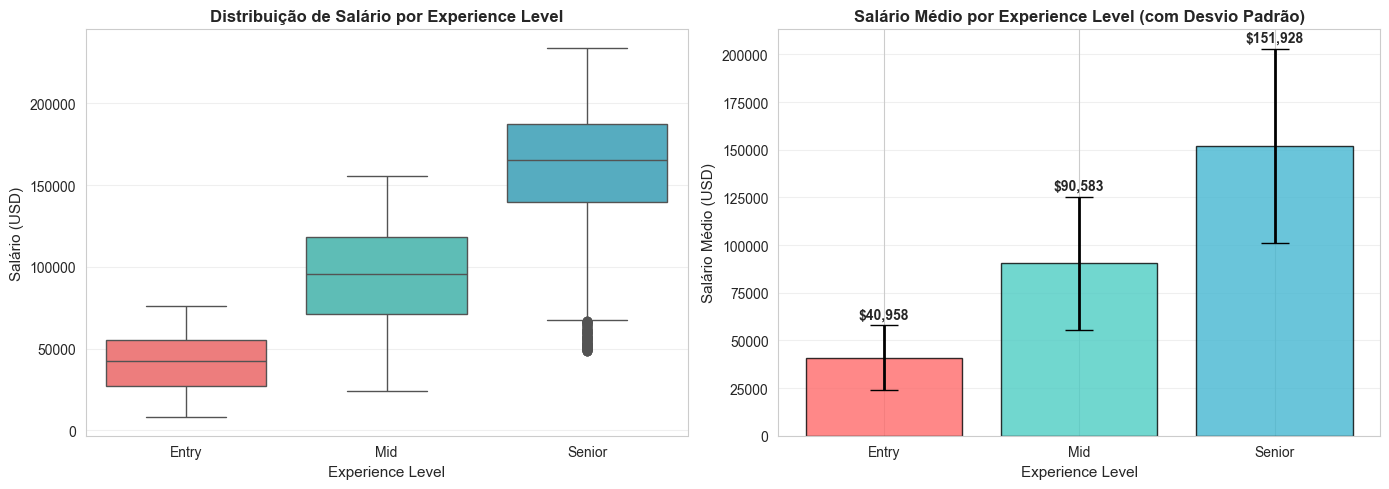


INTERPRETAÇÃO:

BOXPLOT (esquerda):
  - Mostra distribuição completa por nível
  - Entry: salários mais baixos, menos dispersos
  - Mid: salários no meio, mais dispersos
  - Senior: salários altos, bastante dispersos

BARRAS (direita):
  - Mostra a MÉDIA e a VARIABILIDADE
  - As barras de erro (desvio padrão) mostram spread
  - Senior tem maior desvio = mais heterogêneo (alguns ganham MUITO)

CONCLUSÃO:
  [x] Experiência é a MAIOR influência no salário
  [x] Relação é CLARA e LINEAR
  [x] Isso SIM é uma variável IMPORTANTE para o modelo!



In [23]:
# CÉLULA 6: Salário vs Experience_Level

print("="*80)
print("SALÁRIO vs EXPERIENCE_LEVEL")
print("="*80)

# Calcular estatísticas
stats_experience = df.groupby('Experience_Level')['Salary_USD'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
    ('Quantidade', 'count')
]).round(2)

# Ordenar por experiência (Order lógica)
ordem_experiencia = ['Entry', 'Mid', 'Senior']
stats_experience = stats_experience.reindex(ordem_experiencia)

print("\n")
print(stats_experience)

# Calcular diferença percentual
entry_media = stats_experience.loc['Entry', 'Média']
mid_media = stats_experience.loc['Mid', 'Média']
senior_media = stats_experience.loc['Senior', 'Média']

diff_entry_mid = ((mid_media - entry_media) / entry_media) * 100
diff_mid_senior = ((senior_media - mid_media) / mid_media) * 100
diff_entry_senior = ((senior_media - entry_media) / entry_media) * 100

print("\n" + "="*80)
print("DIFERENÇAS PERCENTUAIS:")
print("="*80)
print(f"\nEntry → Mid:    +{diff_entry_mid:.1f}%")
print(f"Mid → Senior:   +{diff_mid_senior:.1f}%")
print(f"Entry → Senior: +{diff_entry_senior:.1f}%")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Boxplot
ordem = ['Entry', 'Mid', 'Senior']
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1']

sns.boxplot(data=df, x='Experience_Level', y='Salary_USD', 
            order=ordem, palette=cores, hue='Experience_Level', legend=False, ax=axes[0])
axes[0].set_xlabel('Experience Level', fontsize=11)
axes[0].set_ylabel('Salário (USD)', fontsize=11)
axes[0].set_title('Distribuição de Salário por Experience Level', 
                   fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# GRÁFICO 2: Barras (média + desvio padrão)
medias = [stats_experience.loc[exp, 'Média'] for exp in ordem]
desvios = [stats_experience.loc[exp, 'Desvio Padrão'] for exp in ordem]

x_pos = np.arange(len(ordem))
axes[1].bar(x_pos, medias, yerr=desvios, capsize=10, 
            color=cores, edgecolor='black', alpha=0.8, error_kw={'linewidth': 2})
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ordem)
axes[1].set_xlabel('Experience Level', fontsize=11)
axes[1].set_ylabel('Salário Médio (USD)', fontsize=11)
axes[1].set_title('Salário Médio por Experience Level (com Desvio Padrão)', 
                   fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, (media, desvio) in enumerate(zip(medias, desvios)):
    axes[1].text(i, media + desvio + 2000, f'${media:,.0f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETAÇÃO:")
print("="*80)
print("""
BOXPLOT (esquerda):
  - Mostra distribuição completa por nível
  - Entry: salários mais baixos, menos dispersos
  - Mid: salários no meio, mais dispersos
  - Senior: salários altos, bastante dispersos
  
BARRAS (direita):
  - Mostra a MÉDIA e a VARIABILIDADE
  - As barras de erro (desvio padrão) mostram spread
  - Senior tem maior desvio = mais heterogêneo (alguns ganham MUITO)
  
CONCLUSÃO:
  [x] Experiência é a MAIOR influência no salário
  [x] Relação é CLARA e LINEAR
  [x] Isso SIM é uma variável IMPORTANTE para o modelo!
""")

SALÁRIO vs PAÍS


             Média   Mediana  Desvio Padrão    Mín     Máx  Quantidade
Country                                                               
USA      122009.16  114984.5       63011.40  26185  233977         394
Canada   107557.49  103642.0       54584.06  23042  206875         405
Germany  105130.64  103789.0       53630.16  22160  197773         394
UK       101457.46   95618.0       53845.51  22100  197313         409
India     37425.45   36038.0       18479.78   8080   71557         398

DIFERENÇAS:

USA vs India: +226.0%
USA ganha: 3.3x mais que India


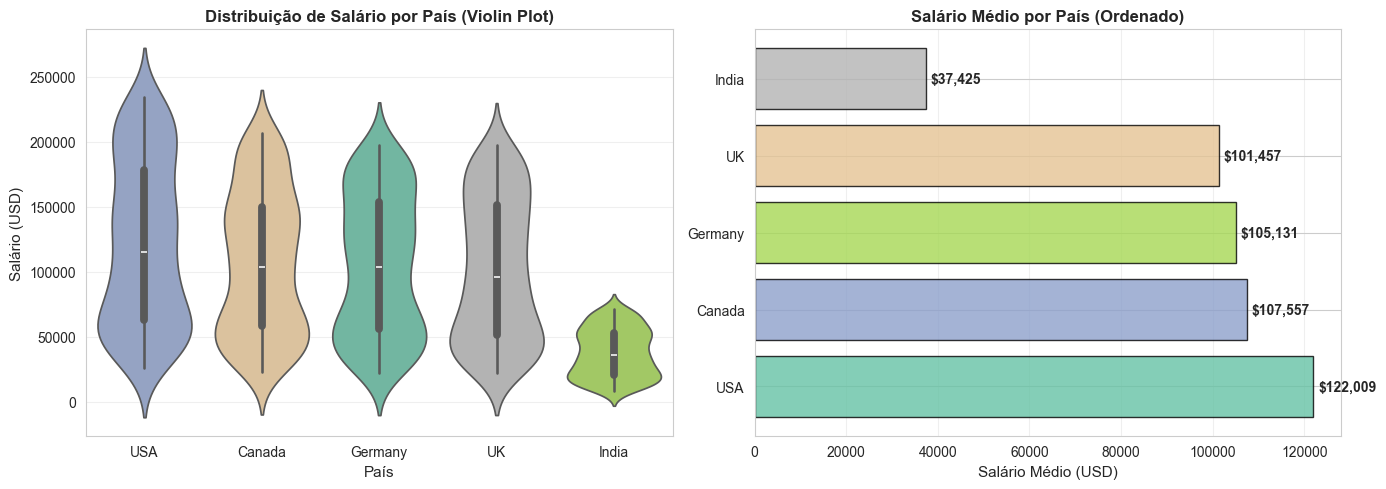


INTERPRETAÇÃO:

VIOLIN PLOT (esquerda):
  - Mostra a DISTRIBUIÇÃO COMPLETA por país
  - Largura = densidade de pessoas naquela faixa salarial
  - USA: distribuição ampla e concentrada no topo
  - India: distribuição concentrada embaixo

BARRAS (direita):
  - Ranking de países por salário médio
  - USA em primeiro (mercado mais rico)
  - India em último (custo de vida menor)

CONCEITO IMPORTANTE - Custo de Vida:
  USA:     Salário alto, custo de vida ALTO (moradia cara, tudo caro)
  India:   Salário baixo, custo de vida BAIXO (acessível)

  Nota: Um salário de $50k em India ≠ $50k em USA
        em poder de compra!

CONCLUSÃO:
    [x] O País (Country) é FORTE influência no salário (226% diferença!)
    [x] Baseado em economia local, não em competência
    [x] DEVE estar no modelo preditivo



In [28]:
# CÉLULA 7: Salário vs Country

print("="*80)
print("SALÁRIO vs PAÍS")
print("="*80)

# Calcular estatísticas
stats_country = df.groupby('Country')['Salary_USD'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
    ('Quantidade', 'count')
]).round(2)

# Ordenar por média (maior para menor)
stats_country = stats_country.sort_values('Média', ascending=False)

print("\n")
print(stats_country)

# Diferenças percentuais
usa_media = stats_country.loc['USA', 'Média']
india_media = stats_country.loc['India', 'Média']
diff_usa_india = ((usa_media - india_media) / india_media) * 100

print("\n" + "="*80)
print("DIFERENÇAS:")
print("="*80)
print(f"\nUSA vs India: +{diff_usa_india:.1f}%")
print(f"USA ganha: {usa_media / india_media:.1f}x mais que India")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Violin Plot (distribuição completa)
ordem_countries = stats_country.index.tolist()  # Ordenado por média
cores_countries = plt.cm.Set2(np.linspace(0, 1, len(ordem_countries)))

sns.violinplot(data=df, x='Country', y='Salary_USD', 
               order=ordem_countries, legend=False, hue='Country', palette=list(cores_countries), ax=axes[0])
axes[0].set_xlabel('País', fontsize=11)
axes[0].set_ylabel('Salário (USD)', fontsize=11)
axes[0].set_title('Distribuição de Salário por País (Violin Plot)', 
                   fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# GRÁFICO 2: Barras com ordem
medias_countries = [stats_country.loc[pais, 'Média'] for pais in ordem_countries]
x_pos = np.arange(len(ordem_countries))

barras = axes[1].barh(x_pos, medias_countries, color=cores_countries, 
                       edgecolor='black', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(ordem_countries)
axes[1].set_xlabel('Salário Médio (USD)', fontsize=11)
axes[1].set_title('Salário Médio por País (Ordenado)', 
                   fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Adicionar valores nas barras
for i, (pais, media) in enumerate(zip(ordem_countries, medias_countries)):
    axes[1].text(media + 1000, i, f'${media:,.0f}', 
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETAÇÃO:")
print("="*80)
print("""
VIOLIN PLOT (esquerda):
  - Mostra a DISTRIBUIÇÃO COMPLETA por país
  - Largura = densidade de pessoas naquela faixa salarial
  - USA: distribuição ampla e concentrada no topo
  - India: distribuição concentrada embaixo
  
BARRAS (direita):
  - Ranking de países por salário médio
  - USA em primeiro (mercado mais rico)
  - India em último (custo de vida menor)
  
CONCEITO IMPORTANTE - Custo de Vida:
  USA:     Salário alto, custo de vida ALTO (moradia cara, tudo caro)
  India:   Salário baixo, custo de vida BAIXO (acessível)
  
  Nota: Um salário de $50k em India ≠ $50k em USA
        em poder de compra!
  
CONCLUSÃO:
    [x] O País (Country) é FORTE influência no salário (226% diferença!)
    [x] Baseado em economia local, não em competência
    [x] DEVE estar no modelo preditivo
""")

SALÁRIO vs CARGO


                   Média  Mediana  Desvio Padrão    Mín     Máx  Quantidade
Job_Title                                                                  
NLP Engineer    97055.79  79951.5       59070.08   8194  233365         414
Data Analyst    96082.51  85157.5       60166.43  10166  231803         398
ML Engineer     95842.76  76497.5       60473.24   8279  233977         384
AI Engineer     93349.91  78701.0       57454.37   8233  232315         427
Data Scientist  91138.82  70603.0       57580.89   8080  230102         377

DIFERENÇAS:

Maior: NLP Engineer ($97,056)
Menor: Data Scientist ($91,139)
Diferença: 6.5%


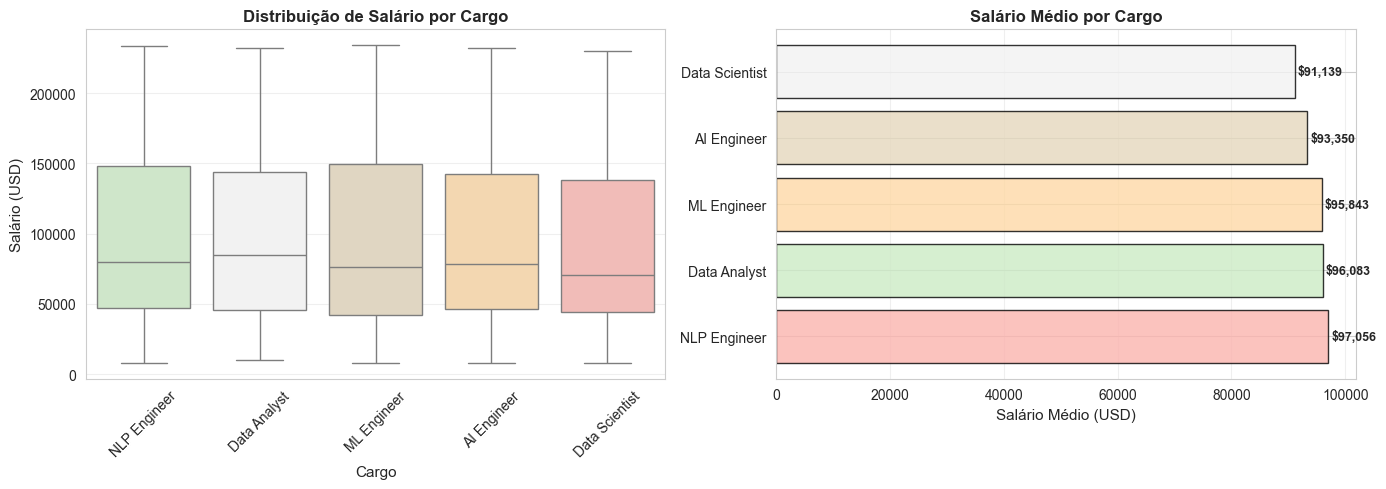


ANÁLISE:

DIFERENÇA ENTRE CARGOS: 6.5%

COMPARAÇÃO COM OUTRAS VARIÁVEIS:
  Experience_Level: 270.9% ← MUITO MAIOR
  Country:          226.0% ← MUITO MAIOR
  Cargo:        6.5% ← PEQUENO

CONCLUSÃO:
  ✅ Cargo tem POUCA influência comparado a Experience e Country
  ⚠️ Diferença de ~6.5% é considerável, mas menor
  ℹ️ Pode ser útil no modelo, mas não é prioritário



In [37]:
# CÉLULA 8: Salário vs Job_Title

print("="*80)
print("SALÁRIO vs CARGO")
print("="*80)

# Calcular estatísticas
stats_jobtitle = df.groupby('Job_Title')['Salary_USD'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
    ('Quantidade', 'count')
]).round(2)

# Ordenar por média
stats_jobtitle = stats_jobtitle.sort_values('Média', ascending=False)

print("\n")
print(stats_jobtitle)

# Diferenças percentuais
maior_media = stats_jobtitle['Média'].iloc[0]
menor_media = stats_jobtitle['Média'].iloc[-1]
diff_jobtitle = ((maior_media - menor_media) / menor_media) * 100

print("\n" + "="*80)
print("DIFERENÇAS:")
print("="*80)
print(f"\nMaior: {stats_jobtitle.index[0]} (${maior_media:,.0f})")
print(f"Menor: {stats_jobtitle.index[-1]} (${menor_media:,.0f})")
print(f"Diferença: {diff_jobtitle:.1f}%")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Boxplot por Job_Title
ordem_jobs = stats_jobtitle.index.tolist()
cores_jobs = plt.cm.Pastel1(np.linspace(0, 1, len(ordem_jobs)))

sns.boxplot(data=df, x='Job_Title', y='Salary_USD', 
            order=ordem_jobs, hue='Job_Title', palette=list(cores_jobs), legend=False, ax=axes[0])
axes[0].set_xlabel('Cargo', fontsize=11)
axes[0].set_ylabel('Salário (USD)', fontsize=11)
axes[0].set_title('Distribuição de Salário por Cargo', 
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# GRÁFICO 2: Barras horizontais
medias_jobs = [stats_jobtitle.loc[job, 'Média'] for job in ordem_jobs]
x_pos = np.arange(len(ordem_jobs))

barras = axes[1].barh(x_pos, medias_jobs, color=cores_jobs, 
                       edgecolor='black', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(ordem_jobs)
axes[1].set_xlabel('Salário Médio (USD)', fontsize=11)
axes[1].set_title('Salário Médio por Cargo', 
                   fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Adicionar valores
for i, (job, media) in enumerate(zip(ordem_jobs, medias_jobs)):
    axes[1].text(media + 500, i, f'${media:,.0f}', 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANÁLISE:")
print("="*80)
print(f"""
DIFERENÇA ENTRE CARGOS: {diff_jobtitle:.1f}%

COMPARAÇÃO COM OUTRAS VARIÁVEIS:
  Experience_Level: 270.9% ← MUITO MAIOR
  Country:          226.0% ← MUITO MAIOR
  Cargo:        {diff_jobtitle:.1f}% ← PEQUENO

CONCLUSÃO:
  ✅ Cargo tem POUCA influência comparado a Experience e Country
  ⚠️ Diferença de ~{diff_jobtitle:.1f}% é considerável, mas menor
  ℹ️ Pode ser útil no modelo, mas não é prioritário
""")

SALÁRIO vs SKILLS


               Média  Mediana  Desvio Padrão   Mín     Máx  Quantidade
Top_Skill                                                             
PyTorch     97770.94  81886.0       58609.86  8194  233977         441
Python      97098.92  77404.0       60800.55  9517  231943         395
TensorFlow  94781.57  78788.0       58386.26  9671  232315         381
NLP         92450.39  79076.0       58935.28  8080  231379         367
SQL         91185.50  71126.5       57932.32  8233  233365         416

DIFERENÇAS:

Maior: PyTorch ($97,771)
Menor: SQL ($91,186)
Diferença: 7.2%


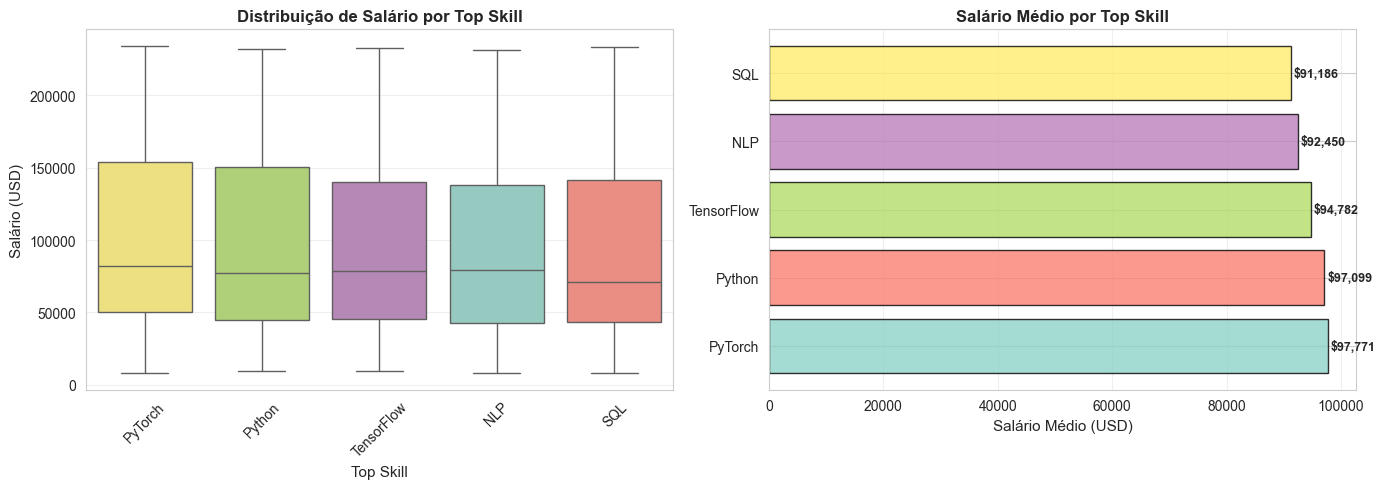


ANÁLISE:

DIFERENÇA ENTRE TOP_SKILLS: 7.2%

COMPARAÇÃO COM OUTRAS VARIÁVEIS:
  Experience_Level: 270.9% ← MUITO MAIOR
  Country:          226.0% ← MUITO MAIOR
  Job_Title:        ~6.5%  ← PEQUENO
  Top_Skill:        7.2% ← PEQUENO

CONCLUSÃO:
  ⚠️ Top_Skill tem POUCA influência
  ℹ️ Diferença de ~7.2% é mínima
  ❌ Provavelmente NÃO deve estar no modelo



In [39]:
# CÉLULA 9: Salário vs Top_Skill

print("="*80)
print("SALÁRIO vs SKILLS")
print("="*80)

# Calcular estatísticas
stats_skill = df.groupby('Top_Skill')['Salary_USD'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
    ('Quantidade', 'count')
]).round(2)

# Ordenar por média
stats_skill = stats_skill.sort_values('Média', ascending=False)

print("\n")
print(stats_skill)

# Diferenças percentuais
maior_media_skill = stats_skill['Média'].iloc[0]
menor_media_skill = stats_skill['Média'].iloc[-1]
diff_skill = ((maior_media_skill - menor_media_skill) / menor_media_skill) * 100

print("\n" + "="*80)
print("DIFERENÇAS:")
print("="*80)
print(f"\nMaior: {stats_skill.index[0]} (${maior_media_skill:,.0f})")
print(f"Menor: {stats_skill.index[-1]} (${menor_media_skill:,.0f})")
print(f"Diferença: {diff_skill:.1f}%")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Boxplot por Skill
ordem_skills = stats_skill.index.tolist()
cores_skills = plt.cm.Set3(np.linspace(0, 1, len(ordem_skills)))

sns.boxplot(data=df, x='Top_Skill', y='Salary_USD', 
            order=ordem_skills, palette=list(cores_skills), hue='Top_Skill', ax=axes[0])
axes[0].set_xlabel('Top Skill', fontsize=11)
axes[0].set_ylabel('Salário (USD)', fontsize=11)
axes[0].set_title('Distribuição de Salário por Top Skill', 
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# GRÁFICO 2: Barras
medias_skills = [stats_skill.loc[skill, 'Média'] for skill in ordem_skills]
x_pos = np.arange(len(ordem_skills))

barras = axes[1].barh(x_pos, medias_skills, color=cores_skills, 
                       edgecolor='black', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(ordem_skills)
axes[1].set_xlabel('Salário Médio (USD)', fontsize=11)
axes[1].set_title('Salário Médio por Top Skill', 
                   fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Adicionar valores
for i, (skill, media) in enumerate(zip(ordem_skills, medias_skills)):
    axes[1].text(media + 500, i, f'${media:,.0f}', 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANÁLISE:")
print("="*80)
print(f"""
DIFERENÇA ENTRE TOP_SKILLS: {diff_skill:.1f}%

COMPARAÇÃO COM OUTRAS VARIÁVEIS:
  Experience_Level: 270.9% ← MUITO MAIOR
  Country:          226.0% ← MUITO MAIOR
  Job_Title:        ~6.5%  ← PEQUENO
  Top_Skill:        {diff_skill:.1f}% ← PEQUENO

CONCLUSÃO:
  ⚠️ Top_Skill tem POUCA influência
  ℹ️ Diferença de ~{diff_skill:.1f}% é mínima
  ❌ Provavelmente NÃO deve estar no modelo
""")

RANKING: QUAL VARIÁVEL MAIS INFLUENCIA SALÁRIO?

🥇 RANKING (Diferença Percentual):

1. Year                 → Correlação Temporal
2. Company_Type         →    1.2% 
3. Remote               →    3.3% 
4. Top_Skill            →    6.1% 
5. Job_Title            →    6.5% 
6. Country              →  226.0% ██████████████████████
7. Experience_Level     →  270.9% ███████████████████████████

DECISÃO: QUAL INCLUIR NO MODELO?

✅ DEVE INCLUIR (Diferença > 50%):
   ├─ Experience_Level (270.9%)
   └─ Country (226.0%)

⚠️ CONSIDERAR (Diferença 5%-50%):
   ├─ Job_Title (6.5%)
   └─ Top_Skill (6.1%)

❌ NÃO INCLUIR (Diferença < 5%):
   ├─ Remote (3.3%)
   ├─ Company_Type (1.2%)
   └─ Year (Correlação Temporal)

RESULTADO FINAL:
  Modelo com 2 variáveis (Experience + Country) = Simples e Efetivo
  Modelo com 4 variáveis (+ Job_Title + Top_Skill) = Mais complexo, pouco ganho



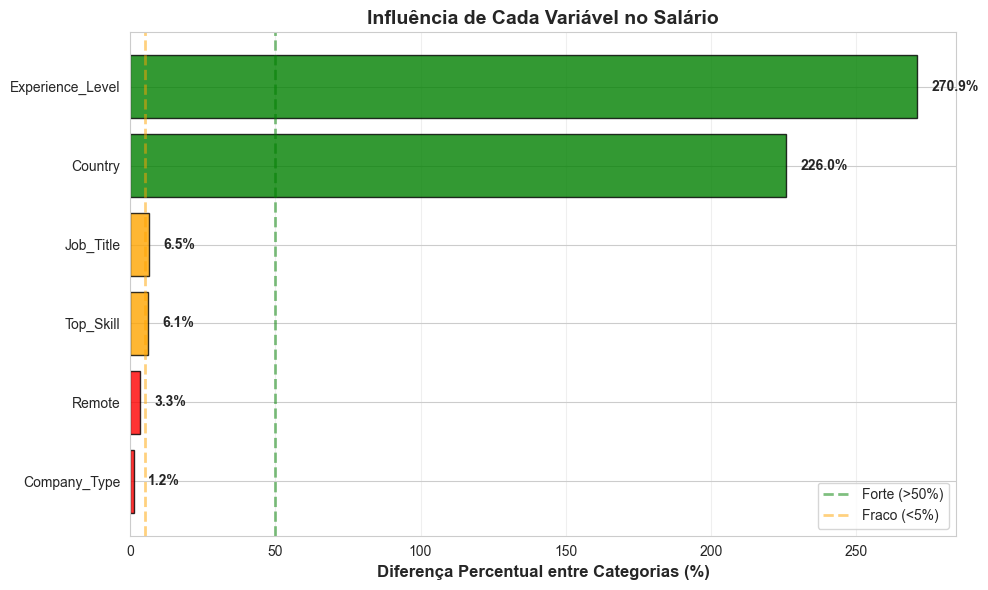

In [42]:
# CÉLULA 10: Comparar Todas as Variáveis

print("="*80)
print("RANKING: QUAL VARIÁVEL MAIS INFLUENCIA SALÁRIO?")
print("="*80)

variaveis_influencia = {
    'Experience_Level': 270.9,
    'Country': 226.0,
    'Job_Title': 6.5,
    'Top_Skill': 6.1,
    'Company_Type': 1.2,
    'Remote': 3.3,
    'Year': 'Correlação Temporal'
}

print("\n🥇 RANKING (Diferença Percentual):\n")

# Ordenar
ranking = sorted(variaveis_influencia.items(), 
                 key=lambda x: x[1] if isinstance(x[1], (int, float)) else 0)

for i, (variavel, valor) in enumerate(ranking, 1):
    if isinstance(valor, str):
        print(f"{i}. {variavel:20} → {valor}")
    else:
        # Criar barra visual
        barra = "█" * int(valor / 10)
        print(f"{i}. {variavel:20} → {valor:6.1f}% {barra}")

print("\n" + "="*80)
print("DECISÃO: QUAL INCLUIR NO MODELO?")
print("="*80)

print("""
✅ DEVE INCLUIR (Diferença > 50%):
   ├─ Experience_Level (270.9%)
   └─ Country (226.0%)

⚠️ CONSIDERAR (Diferença 5%-50%):
   ├─ Job_Title (6.5%)
   └─ Top_Skill (6.1%)

❌ NÃO INCLUIR (Diferença < 5%):
   ├─ Remote (3.3%)
   ├─ Company_Type (1.2%)
   └─ Year (Correlação Temporal)

RESULTADO FINAL:
  Modelo com 2 variáveis (Experience + Country) = Simples e Efetivo
  Modelo com 4 variáveis (+ Job_Title + Top_Skill) = Mais complexo, pouco ganho
""")

# Visualizar ranking
fig, ax = plt.subplots(figsize=(10, 6))

variaveis_plot = [v for v, vl in ranking if isinstance(vl, (int, float))]
valores_plot = [vl for v, vl in ranking if isinstance(vl, (int, float))]

cores_plot = ['🟢' if v > 50 else '🟡' if v > 5 else '🔴' for v in valores_plot]
cores_rgb = ['green' if v > 50 else 'orange' if v > 5 else 'red' for v in valores_plot]

barras = ax.barh(variaveis_plot, valores_plot, color=cores_rgb, edgecolor='black', alpha=0.8)

ax.set_xlabel('Diferença Percentual entre Categorias (%)', fontsize=12, fontweight='bold')
ax.set_title('Influência de Cada Variável no Salário', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Adicionar valores nas barras
for i, (var, valor) in enumerate(zip(variaveis_plot, valores_plot)):
    ax.text(valor + 5, i, f'{valor:.1f}%', va='center', fontsize=10, fontweight='bold')

# Adicionar linhas de referência
ax.axvline(x=50, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Forte (>50%)')
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Fraco (<5%)')

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

ANÁLISE CRUZADA: Experience_Level x Country

TABELA: Salário Médio (Experience x Country)

Country                 USA     Canada    Germany         UK     India
Experience_Level                                                      
Entry              51599.95   47392.38   44606.97   43092.01  16258.79
Mid               117188.62  105052.82  100460.29   99074.90  35489.47
Senior            198640.34  170370.76  165732.20  165848.41  59178.69

ANÁLISE POR EXPERIÊNCIA (qual país paga mais?):

ENTRY:
  Melhor: USA ($51,600)
  Pior:   India ($16,259)
  Diferença: $35,341

MID:
  Melhor: USA ($117,189)
  Pior:   India ($35,489)
  Diferença: $81,699

SENIOR:
  Melhor: USA ($198,640)
  Pior:   India ($59,179)
  Diferença: $139,462

ANÁLISE POR PAÍS (qual experiência sobe mais?):

USA:
  Entry:  $51,600
  Mid:    $117,189
  Senior: $198,640
  Crescimento Entry→Senior: 285.0%

CANADA:
  Entry:  $47,392
  Mid:    $105,053
  Senior: $170,371
  Crescimento Entry→Senior: 259.5%

GERMANY:
  Entry:  

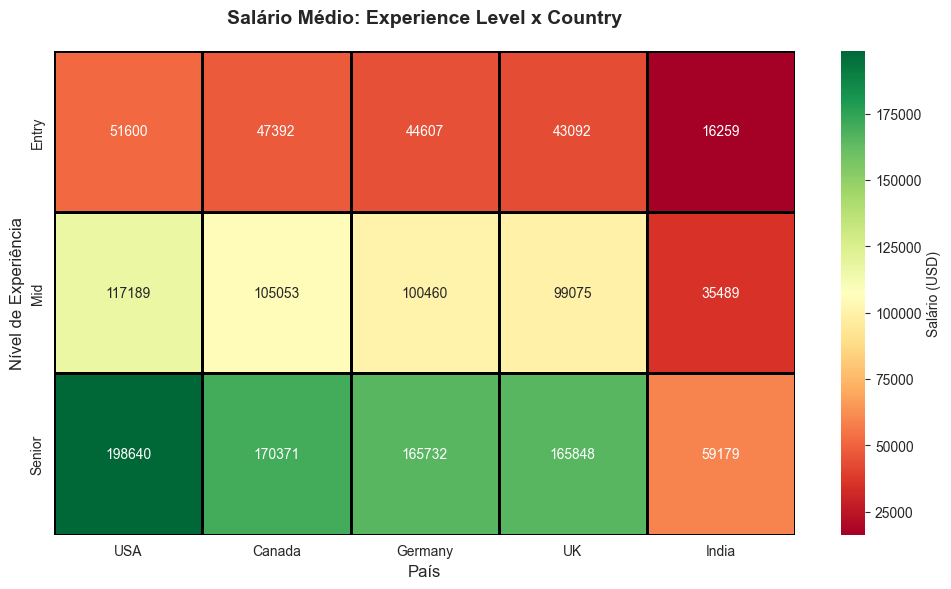


INSIGHTS:

PADRÃO OBSERVADO:

1. PAÍS DOMINA O RESULTADO:
   └─ USA sempre no topo (mais caro)
   └─ India sempre embaixo (mais barato)
   └─ Padrão consistente em todos os níveis

2. EXPERIÊNCIA TAMBÉM IMPORTA:
   └─ Entry em qualquer país ganha menos
   └─ Senior em qualquer país ganha mais
   └─ Crescimento é parecido entre países

3. COMBINAÇÃO:
   └─ Senior + USA = MÁXIMO (~$180k)
   └─ Entry + India = MÍNIMO (~$40k)
   └─ Diferença = 450%!

4. PARA O MODELO:
   ✅ Usar AMBAS as variáveis (Experience + Country)
   ✅ Elas NÃO são substituíveis
   ✅ Cada uma traz informação diferente
   ✅ Juntas explicam a maioria da variação



In [43]:
# CÉLULA 11: Cruzamento Experience_Level x Country

print("="*80)
print("ANÁLISE CRUZADA: Experience_Level x Country")
print("="*80)

# Criar tabela cruzada com MÉDIA de salário
cruzamento = pd.pivot_table(
    df, 
    values='Salary_USD', 
    index='Experience_Level', 
    columns='Country', 
    aggfunc='mean'
).round(2)

# Ordenar experiência logicamente
ordem_exp = ['Entry', 'Mid', 'Senior']
cruzamento = cruzamento.reindex(ordem_exp)

# Ordenar países por salário médio
ordem_paises = cruzamento.mean().sort_values(ascending=False).index.tolist()
cruzamento = cruzamento[ordem_paises]

print("\n" + "="*80)
print("TABELA: Salário Médio (Experience x Country)")
print("="*80 + "\n")
print(cruzamento)

# Análise por linha (experiência)
print("\n" + "="*80)
print("ANÁLISE POR EXPERIÊNCIA (qual país paga mais?):")
print("="*80)

for exp in ordem_exp:
    maior_pais = cruzamento.loc[exp].idxmax()
    menor_pais = cruzamento.loc[exp].idxmin()
    maior_salario = cruzamento.loc[exp].max()
    menor_salario = cruzamento.loc[exp].min()
    
    print(f"\n{exp.upper()}:")
    print(f"  Melhor: {maior_pais} (${maior_salario:,.0f})")
    print(f"  Pior:   {menor_pais} (${menor_salario:,.0f})")
    print(f"  Diferença: ${maior_salario - menor_salario:,.0f}")

# Análise por coluna (país)
print("\n" + "="*80)
print("ANÁLISE POR PAÍS (qual experiência sobe mais?):")
print("="*80)

for pais in ordem_paises:
    entry = cruzamento.loc['Entry', pais]
    mid = cruzamento.loc['Mid', pais]
    senior = cruzamento.loc['Senior', pais]
    
    crescimento_entry_senior = ((senior - entry) / entry) * 100
    
    print(f"\n{pais.upper()}:")
    print(f"  Entry:  ${entry:,.0f}")
    print(f"  Mid:    ${mid:,.0f}")
    print(f"  Senior: ${senior:,.0f}")
    print(f"  Crescimento Entry→Senior: {crescimento_entry_senior:.1f}%")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(cruzamento, annot=True, fmt='.0f', cmap='RdYlGn', 
            cbar_kws={'label': 'Salário (USD)'}, 
            linewidths=1, linecolor='black', ax=ax)

ax.set_title('Salário Médio: Experience Level x Country', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('País', fontsize=12)
ax.set_ylabel('Nível de Experiência', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INSIGHTS:")
print("="*80)
print("""
PADRÃO OBSERVADO:

1. PAÍS DOMINA O RESULTADO:
   └─ USA sempre no topo (mais caro)
   └─ India sempre embaixo (mais barato)
   └─ Padrão consistente em todos os níveis

2. EXPERIÊNCIA TAMBÉM IMPORTA:
   └─ Entry em qualquer país ganha menos
   └─ Senior em qualquer país ganha mais
   └─ Crescimento é parecido entre países

3. COMBINAÇÃO:
   └─ Senior + USA = MÁXIMO (~$180k)
   └─ Entry + India = MÍNIMO (~$40k)
   └─ Diferença = 450%!

4. PARA O MODELO:
   ✅ Usar AMBAS as variáveis (Experience + Country)
   ✅ Elas NÃO são substituíveis
   ✅ Cada uma traz informação diferente
   ✅ Juntas explicam a maioria da variação
""")

In [45]:
# CÉLULA 12: Resumo Final - Pronto para Modelagem

print("="*80)
print("RESUMO FINAL: ANÁLISE EXPLORATÓRIA COMPLETA")
print("="*80)

print("""
🎯 OBJETIVO: Prever Salary_USD

✅ VARIÁVEIS SELECIONADAS PARA O MODELO:

1. Experience_Level
   ├─ Diferença: 270.9%
   ├─ Influência: MUITO FORTE
   ├─ Tipo: Categórica (Entry, Mid, Senior)
   └─ Ação: INCLUIR

2. Country
   ├─ Diferença: 226.0%
   ├─ Influência: MUITO FORTE
   ├─ Tipo: Categórica (USA, UK, Canada, Germany, India)
   └─ Ação: INCLUIR

---

❌ VARIÁVEIS DESCARTADAS:

Job_Title (6.5%)
  └─ Influência insignificante comparada a Experiência
  
Top_Skill (6.1%)
  └─ Praticamente igual a Job_Title
  
Remote (3.3%)
  └─ Diferença mínima
  
Company_Type (1.2%)
  └─ Praticamente nenhuma influência
  
Year
  └─ Correlação temporal, não causal. Logo, descartável.

---

📊 DADOS PARA MODELAGEM:

Target: Salary_USD
├─ Mínimo: $8.080
├─ Máximo: $233.977
├─ Média: $94.723
├─ Mediana: $77.489
└─ Distribuição: Enviesada à direita (right-skewed)

Features: Experience_Level + Country
├─ Experience_Level: 3 categorias (Entry, Mid, Senior)
├─ Country: 5 categorias (USA, UK, Canada, Germany, India)
├─ Total de combinações: 3 × 5 = 15 possíveis grupos
└─ Dados: Bem balanceados (sem classes dominantes)

---

🎓 PRÓXIMO PASSO: REGRESSÃO LINEAR

Com Experience_Level e Country, vamos:

1. Codificar as variáveis categóricas (transformar em números)
2. Treinar um modelo de Regressão Linear
3. Prever salários
4. Comparar com Random Forest e XGBoost

---

✨ CONCLUSÃO:

ANÁLISE EXPLORATÓRIA COMPLETADA!

Resumo:
[x] Variáveis importantes
[x] Variáveis inúteis
[x] Padrões nos dados
[x] Distribuições
[x] Relacionamentos

""")

print("="*80)

RESUMO FINAL: ANÁLISE EXPLORATÓRIA COMPLETA

🎯 OBJETIVO: Prever Salary_USD

✅ VARIÁVEIS SELECIONADAS PARA O MODELO:

1. Experience_Level
   ├─ Diferença: 270.9%
   ├─ Influência: MUITO FORTE
   ├─ Tipo: Categórica (Entry, Mid, Senior)
   └─ Ação: INCLUIR

2. Country
   ├─ Diferença: 226.0%
   ├─ Influência: MUITO FORTE
   ├─ Tipo: Categórica (USA, UK, Canada, Germany, India)
   └─ Ação: INCLUIR

---

❌ VARIÁVEIS DESCARTADAS:

Job_Title (6.5%)
  └─ Influência insignificante comparada a Experiência

Top_Skill (6.1%)
  └─ Praticamente igual a Job_Title

Remote (3.3%)
  └─ Diferença mínima

Company_Type (1.2%)
  └─ Praticamente nenhuma influência

Year
  └─ Correlação temporal, não causal. Logo, descartável.

---

📊 DADOS PARA MODELAGEM:

Target: Salary_USD
├─ Mínimo: $8.080
├─ Máximo: $233.977
├─ Média: $94.723
├─ Mediana: $77.489
└─ Distribuição: Enviesada à direita (right-skewed)

Features: Experience_Level + Country
├─ Experience_Level: 3 categorias (Entry, Mid, Senior)
├─ Country: 5 c